# LArXe Light Yield (Liq. #6)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import uproot
import sipm.recon.WaveformDataset as wfd
import sipm.util.functions as func
import sipm.util.spectrum as spectrum

plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'xtick.minor.visible': True, 'ytick.minor.visible': True, 'axes.grid': True})

## Read calibration file and get SPE gain

In [2]:
calib = {}
pe_scale = {}
voltages = [92,94,96,98,100]
for volt in voltages:
    calib[volt] = pd.read_hdf('/home/as111/sipm-analysis/data/calibration_liq6_2023-12-13.h5', key=f'{volt}V')
    pe_scale[volt] = calib[volt]['Qavg']/(1-calib[volt]['DiCT'])

## G4DS simulation (Compton scattering + UV photon transport)

<TH1D (version 3) at 0x152abf87ab20>
<TH1D (version 3) at 0x152abf7d5220>
<TH1D (version 3) at 0x152abf7e9b20>
<TH1D (version 3) at 0x152abf7d5e50>


Text(0.5, 1.0, 'Geant-4 Spectra')

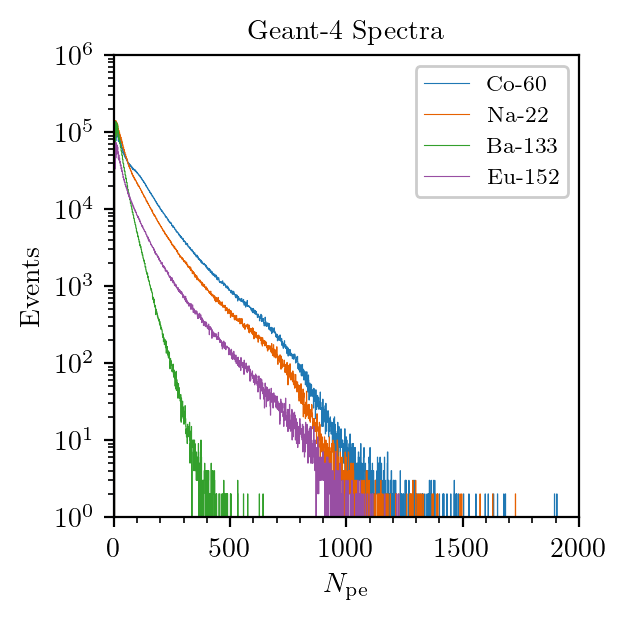

In [3]:
src = {'Co-60':'co60','Na-22':'na22','Ba-133':'ba133','Eu-152':'eu152'}
hist_sim = {}
plt.figure(0,figsize=(3,3))
for S,s in src.items():
	rtf = uproot.open(f'/home/as111/sipm-analysis/data/pe_hist/no_reflection/pu_lar_{s}_hist.root')
	try:
		hist_sim[S] = rtf['nph_wl_tba0p3'].to_numpy()
		print(rtf['nph_wl_tba0p3'])
		plt.stairs(hist_sim[S][0],hist_sim[S][1],linewidth=0.4,label=S)
	except uproot.KeyInFileError:
		print(f'{s} no such key')
plt.grid()
plt.minorticks_on()
plt.yscale('log')
plt.xlabel(r'$N_{\rm pe}$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.title('Geant-4 Spectra')

## Visualize raw waveforms

trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-02-16/2024-02-16_volt_98_light_scintillation_source_co60_xenon_0_cond_gamma/0/wave0.dat
95 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-02-16/2024-02-16_volt_98_light_scintillation_source_co60_xenon_0_cond_gamma/0/wave1.dat
95 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-02-16/2024-02-16_volt_98_light_scintillation_source_co60_xenon_0_cond_gamma/0/wave2.dat
95 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-02-16/2024-02-16_volt_98_light_scintillation_source_co60_xenon_0_cond_gamma/0/wave3.dat
95 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-02-16/2024-02-16_volt_98_light_scintillation_source_co60_xenon_0_cond_gamma/0/wave4.dat
95 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-02-16/2024-02-

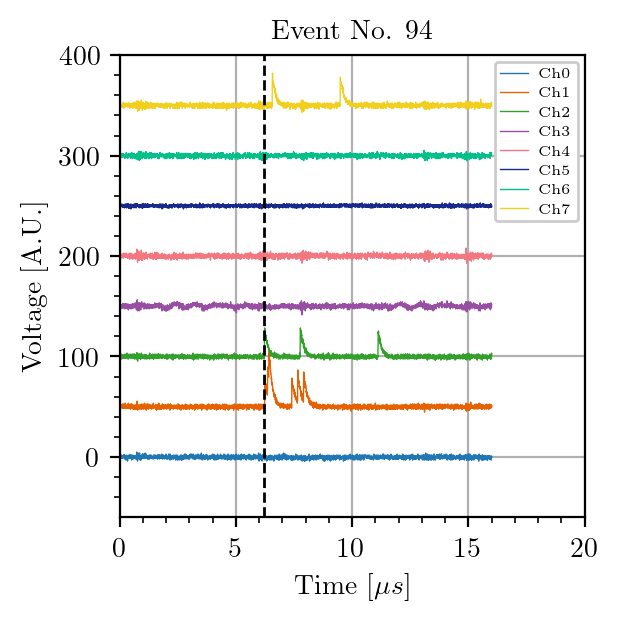

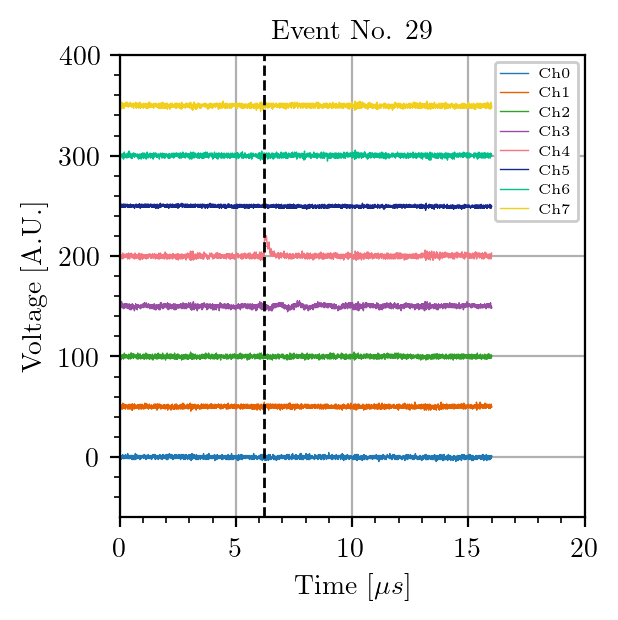

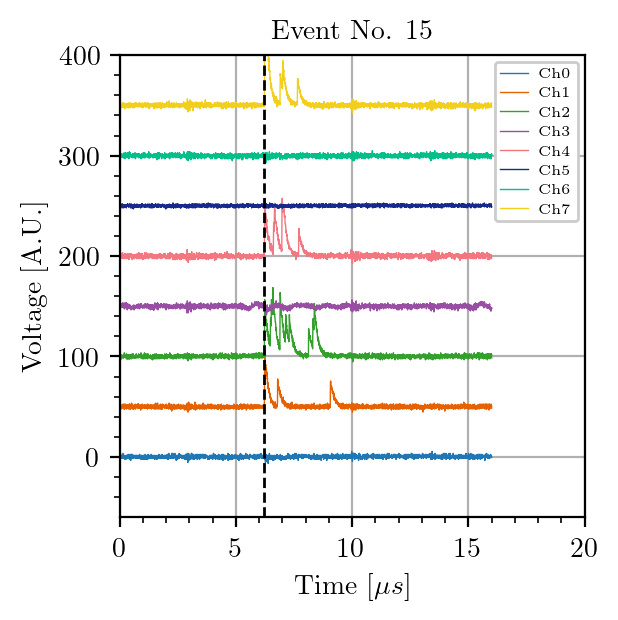

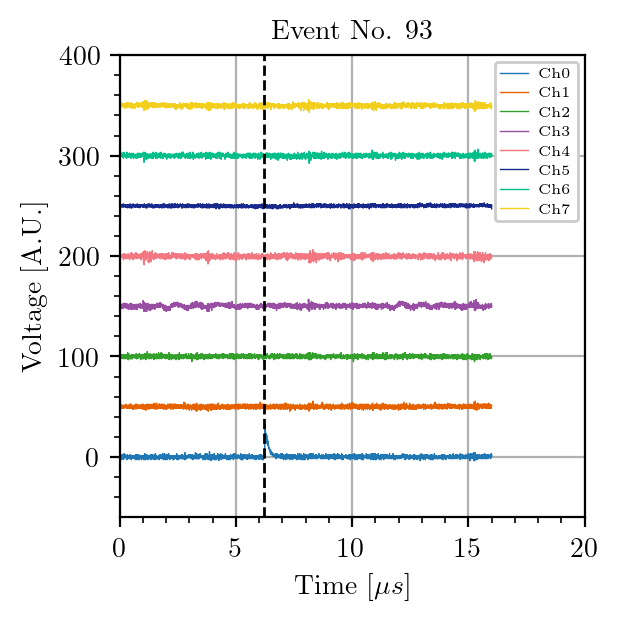

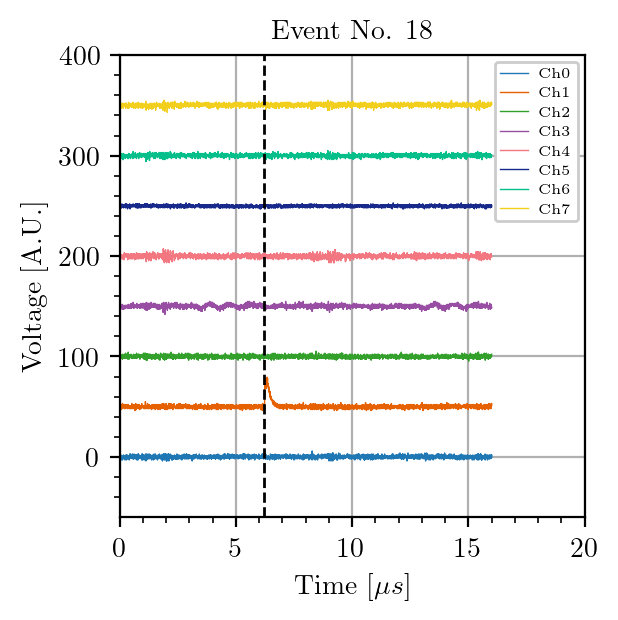

In [4]:
evid = np.random.randint(0,100,5)
trig = 1555
dt = 4e-3
dset = wfd.WaveformDataset(
    path='/scratch/gpfs/GALBIATI/data/sipm/xenon_doping/2024-02-16/2024-02-16_volt_98_light_scintillation_source_co60_xenon_0_cond_gamma/0/', 
    pol=-1, 
    channels=range(8),
    trig=trig)
wfs = []
for ch in np.arange(8):
    wfs.append(dset.ch[ch].get_waveforms(ev=evid, ar_filter=False)[0])
wfs = np.array(wfs)
print(wfs.shape)
for i in range(wfs.shape[1]):
    plt.figure(i, figsize=(3, 3))
    for ch in range(wfs.shape[0]):
        plt.plot(dset.ch[ch].time, wfs[ch,i]+ch*50, label=f'Ch{ch}', linewidth=0.5)
    plt.plot([dt*trig]*2, [-60,400],'k--',lw=1)
    plt.legend(loc='upper right', fontsize=5)
    plt.xlabel(r'Time [$\mu s$]')
    plt.ylabel(r'Voltage [A.U.]')
    plt.ylim(-60, 400)
    plt.title(f'Event No. {evid[i]}')

## Load pre-processed h5

Na-22 data at equilibrium

In [5]:
path = "/scratch/gpfs/GALBIATI/as111/results/"
xe_ppm = [0,2.7,5.0,10.0,20.0,40.0]
files = [glob(f"{path}*/*source_na22*xenon_{i}*scintillation_pulse_liq6.h5") for i in range(len(xe_ppm))]
for i in range(len(xe_ppm)):
    print(len(files[i]), files[i])

10 ['/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run9_scintillation_pulse_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run2_scintillation_pulse_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run3_scintillation_pulse_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run1_scintillation_pulse_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run8_scintillation_pulse_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run0_scintillation_pulse_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_ligh

In [6]:
data = []
channels = np.arange(-1,8)
volt = 98

for i,x in enumerate(xe_ppm):
	df,_ = spectrum.load_data(files[i],channels,volt)
	data.append(df)
	df = None
	print(f'Na-22 {x}ppm: {data[i].shape[0]} events')
print('columns: ', list(data[0].columns))

Na-22 0ppm: 502997 events
Na-22 2.7ppm: 503555 events
Na-22 5.0ppm: 503578 events
Na-22 10.0ppm: 503448 events
Na-22 20.0ppm: 503283 events
Na-22 40.0ppm: 503130 events
columns:  ['start_datetime', 'end_datetime', 'duration_seconds', 'nch', 'nch_fs', 'nch_nofs', 'total_pe', 'fprompt_0p30us_01234567', 'fprompt_0p30us_0356', 'fprompt_0p30us_1247', 'baseline_mean_0', 'baseline_rms_0', 'integral_0p30us_0', 'integral_5p00us_0', 'integral_9p60us_0', 'fired_0', 'amplitude_0', 'peakpos_0', 'baseline_mean_1', 'baseline_rms_1', 'integral_0p30us_1', 'integral_5p00us_1', 'integral_9p60us_1', 'fired_1', 'amplitude_1', 'peakpos_1', 'baseline_mean_2', 'baseline_rms_2', 'integral_0p30us_2', 'integral_5p00us_2', 'integral_9p60us_2', 'fired_2', 'amplitude_2', 'peakpos_2', 'baseline_mean_3', 'baseline_rms_3', 'integral_0p30us_3', 'integral_5p00us_3', 'integral_9p60us_3', 'fired_3', 'amplitude_3', 'peakpos_3', 'baseline_mean_4', 'baseline_rms_4', 'integral_0p30us_4', 'integral_5p00us_4', 'integral_9p60us_

## Reconstruct $N_{pe}$ and $f_{prompt}$

In [7]:
# pe count by channel
col_names = ['9p60us','0p30us']
for i, x in enumerate(xe_ppm):
	for col in col_names:
		for ch in np.arange(8):
			data[i][f'pe_{col}_{ch}'] = data[i][f'integral_{col}_{ch}']/pe_scale[98][ch]

In [8]:
# pe count wl & ww
channels_wl = [1,2,4,7]
channels_ww = [0,3,6]
for i, x in enumerate(xe_ppm):
	for col in col_names:
		data[i][f'pe_{col}_wl'] = data[i][[f'pe_{col}_{ch}' for ch in channels_wl]].sum(axis=1)
		data[i][f'pe_{col}_ww'] = data[i][[f'pe_{col}_{ch}' for ch in channels_ww]].sum(axis=1)

In [9]:
# fprompt wl
short_name = '0p30us'
long_name = '9p60us'
for i, x in enumerate(xe_ppm):
	data[i]['fprompt'] = data[i][[f'pe_{short_name}_{ch}' for ch in channels_wl]].sum(axis=1) / data[i][[f'pe_{long_name}_{ch}' for ch in channels_wl]].sum(axis=1)

In [10]:
# top-bottom asymmetry
channels_top = [4,7]
channels_bot = [1,2]
for i, x in enumerate(xe_ppm):
	top = data[i][[f'pe_9p60us_{ch}' for ch in channels_top]].sum(axis=1)
	bot = data[i][[f'pe_9p60us_{ch}' for ch in channels_bot]].sum(axis=1)
	data[i]['tba'] = (top-bot)/(top+bot)

## Apply RMS cut

In [11]:
rms_threshold = [2.0,2.0,2.0,2.0,2.3,2.0,2.0,2.0]
for i, x in enumerate(xe_ppm):
	df_bsl_filt = spectrum.get_bsl_filt(data[i],np.arange(8),rms_threshold)
	data[i][df_bsl_filt.columns] = df_bsl_filt
	df_bsl_filt = None

## Fprompt Distribution

/tmp/ipykernel_2833045/499509339.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(h[1],h[2],np.log10(h[0]).T)
/tmp/ipykernel_2833045/499509339.py:16: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.pcolormesh(h[1],h[2],np.log10(h[0]).T)


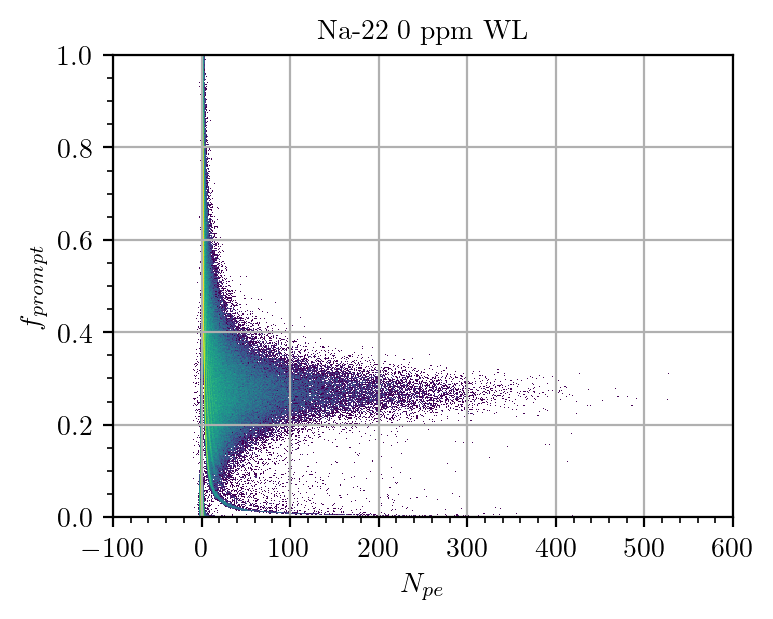

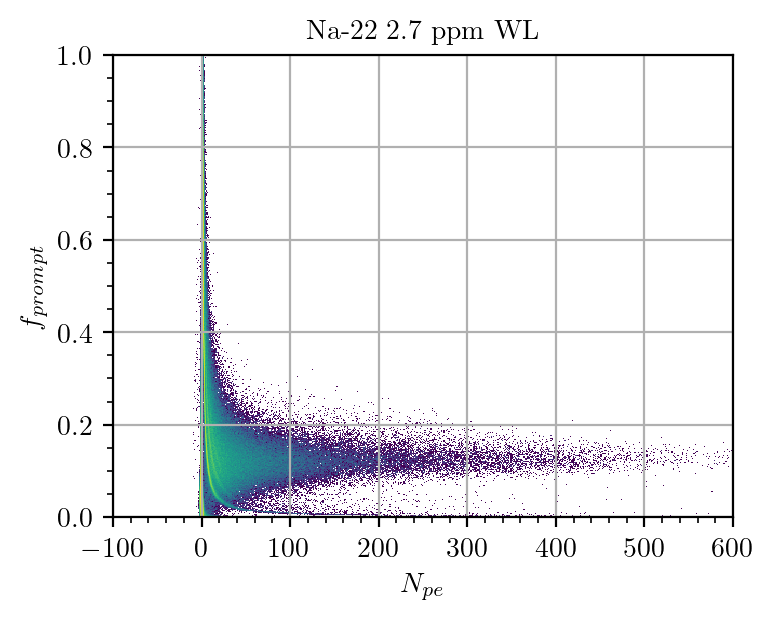

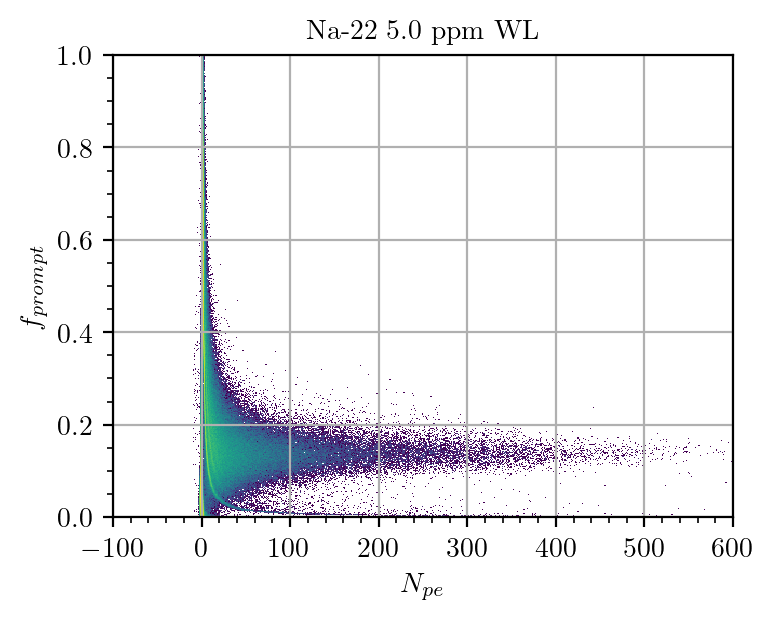

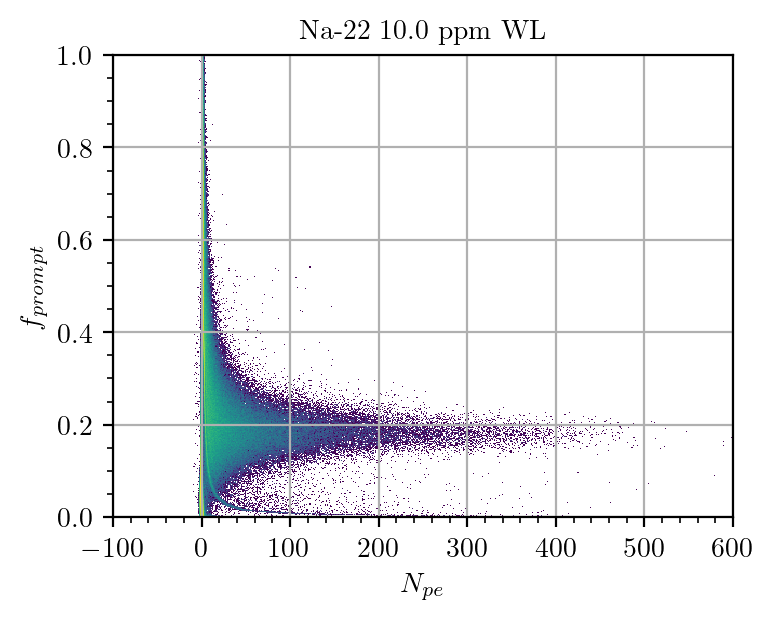

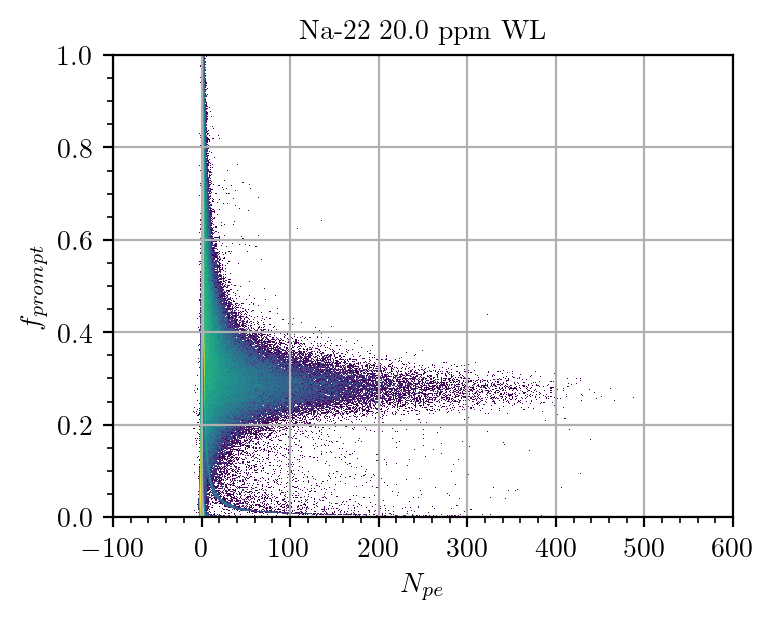

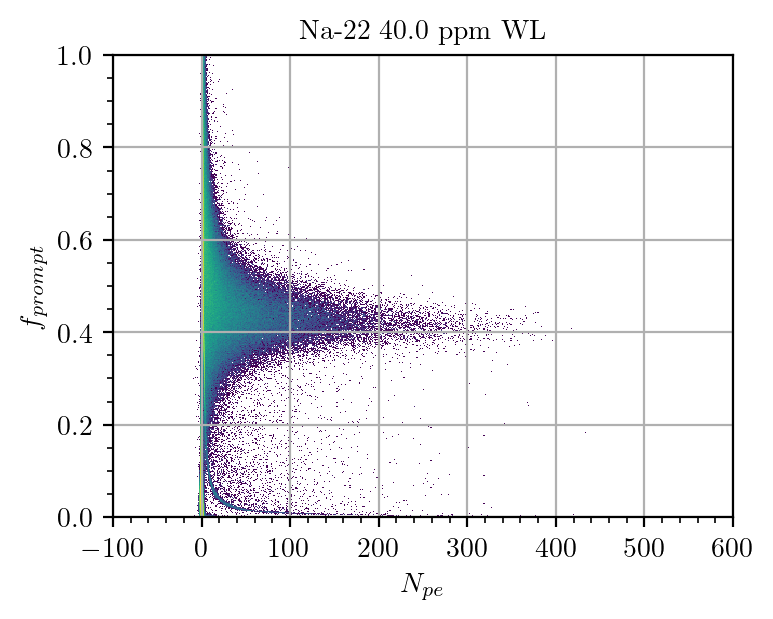

In [12]:
# Initialize container
fprompt = {}

# Produce fprompt 2D histograms
binsx = 500
range_minx = -10
range_maxx = 600
binsy = 500
range_miny = 0
range_maxy = 1

for i, x in enumerate(xe_ppm):
	plt.figure(i)
	filt = data[i]['bsl_filt'] & (data[i]['amplitude_1']<1200) & (data[i]['amplitude_2']<1200) & (data[i]['amplitude_4']<1200) & (data[i]['amplitude_7']<1200)
	h = np.histogram2d(data[i][filt]['pe_9p60us_wl'],data[i][filt]['fprompt'],bins=[binsx,binsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]])
	plt.pcolormesh(h[1],h[2],np.log10(h[0]).T)
	plt.xlabel(r'$N_{pe}$')
	plt.ylabel(r'$f_{prompt}$')
	plt.title(f'Na-22 {x} ppm WL')
	plt.grid()

## $N_{pe}$ Spectra

In [13]:
spectra = {}
window = ['yes', 'no']
for i,x in enumerate(xe_ppm):
	spectra[i] = {}
	for w in window:
		spectra[i][w] = {}
		if w=='yes':
			range_min = -10
			range_max = 2000
			nbins = 1000
		elif w=='no':
			range_min = -10
			range_max = 4000
			nbins = 1000
		filt = data[i]['bsl_filt'] & (data[i]['fprompt']>0.05) & (np.abs(data[i]['tba'])<0.3)
		spectra[i][w]['counts'], spectra[i][w]['bins'] = np.histogram(
			data[i]['pe_9p60us_wl'][filt] if w=='no' else data[i]['pe_9p60us_ww'][filt],
			bins=nbins, range=(range_min, range_max)
		)
		spectra[i][w]['errs'] = np.sqrt(spectra[i][w]['counts'])

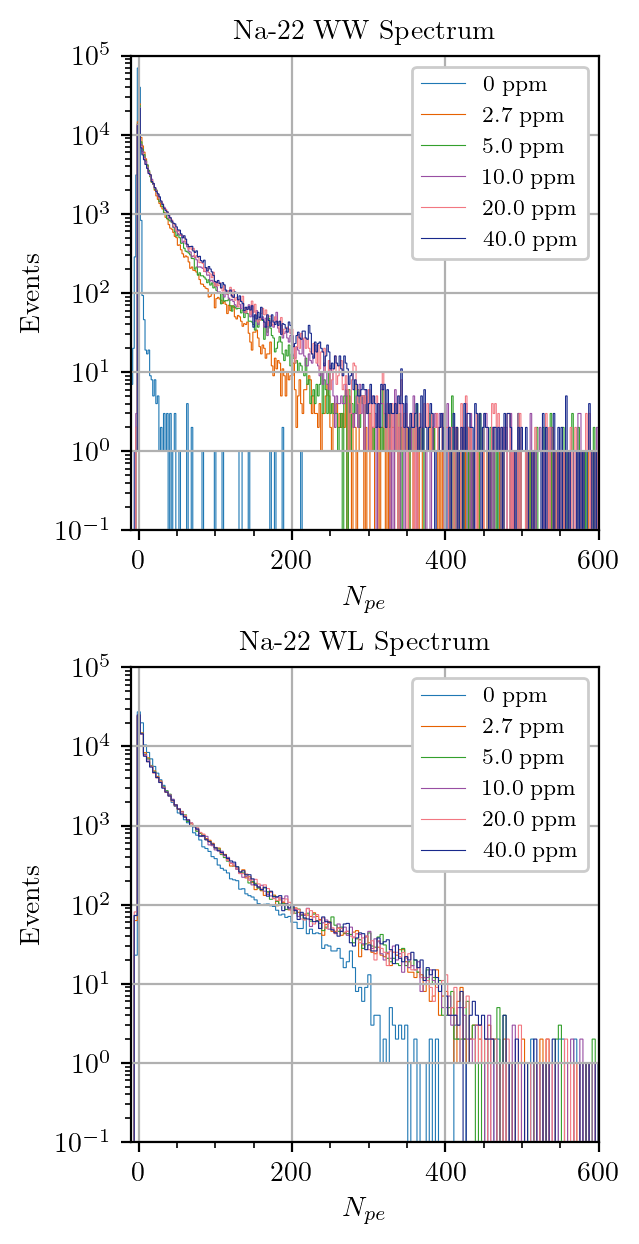

In [14]:
fig, axs = plt.subplots(2, 1, sharex=False, sharey=True)
fig.set_size_inches(3, 6)
fig.tight_layout(h_pad=3)
for i,w in enumerate(window):
	for k,x in enumerate(xe_ppm):
		axs[i].stairs(
			spectra[k][w]['counts'], 
			spectra[k][w]['bins'], 
			label=f'{x} ppm', color=f'C{k}', linewidth=0.4
		)
	axs[i].legend(loc='upper right')
	axs[i].set_ylim(1e-1, 1e5)
	axs[i].set_xlim(-10, 600)
	axs[i].set_yscale('log')
	axs[i].set_title('Na-22 '+('WL' if w=='no' else 'WW')+' Spectrum')
	axs[i].set_xlabel(r'$N_{pe}$')
	axs[i].set_ylabel('Events')

## Spectrum Fitting

(0.049999999999998934, 0.09999999999999787)
Na-22 0ppm WW MC fit failed
(98.53999999999999, 197.07999999999998)
Na-22 2.7ppm WW [2.03184395e+05 2.51401889e-01]
(118.63999999999999, 237.27999999999997)
Na-22 5.0ppm WW [2.09518932e+05 2.97943044e-01]
(136.73, 273.46)
Na-22 10.0ppm WW [2.25460556e+05 3.33007360e-01]
(150.79999999999998, 301.59999999999997)
Na-22 20.0ppm WW [2.41417900e+05 3.54452941e-01]
(156.82999999999998, 313.65999999999997)
Na-22 40.0ppm WW [2.02959802e+05 3.95575745e-01]
(186.48999999999998, 372.97999999999996)
Na-22 0ppm WL [5.59430382e+05 3.61977058e-01]
(246.64, 493.28)
Na-22 2.7ppm WL [4.77602188e+05 4.97260573e-01]
(254.65999999999997, 509.31999999999994)
Na-22 5.0ppm WL [5.04413574e+05 5.00029625e-01]
(254.65999999999997, 509.31999999999994)
Na-22 10.0ppm WL [5.16211955e+05 5.01098504e-01]
(254.65999999999997, 509.31999999999994)
Na-22 20.0ppm WL [4.79040594e+05 5.07858703e-01]
(262.68, 525.36)
Na-22 40.0ppm WL [5.03618207e+05 5.09775388e-01]


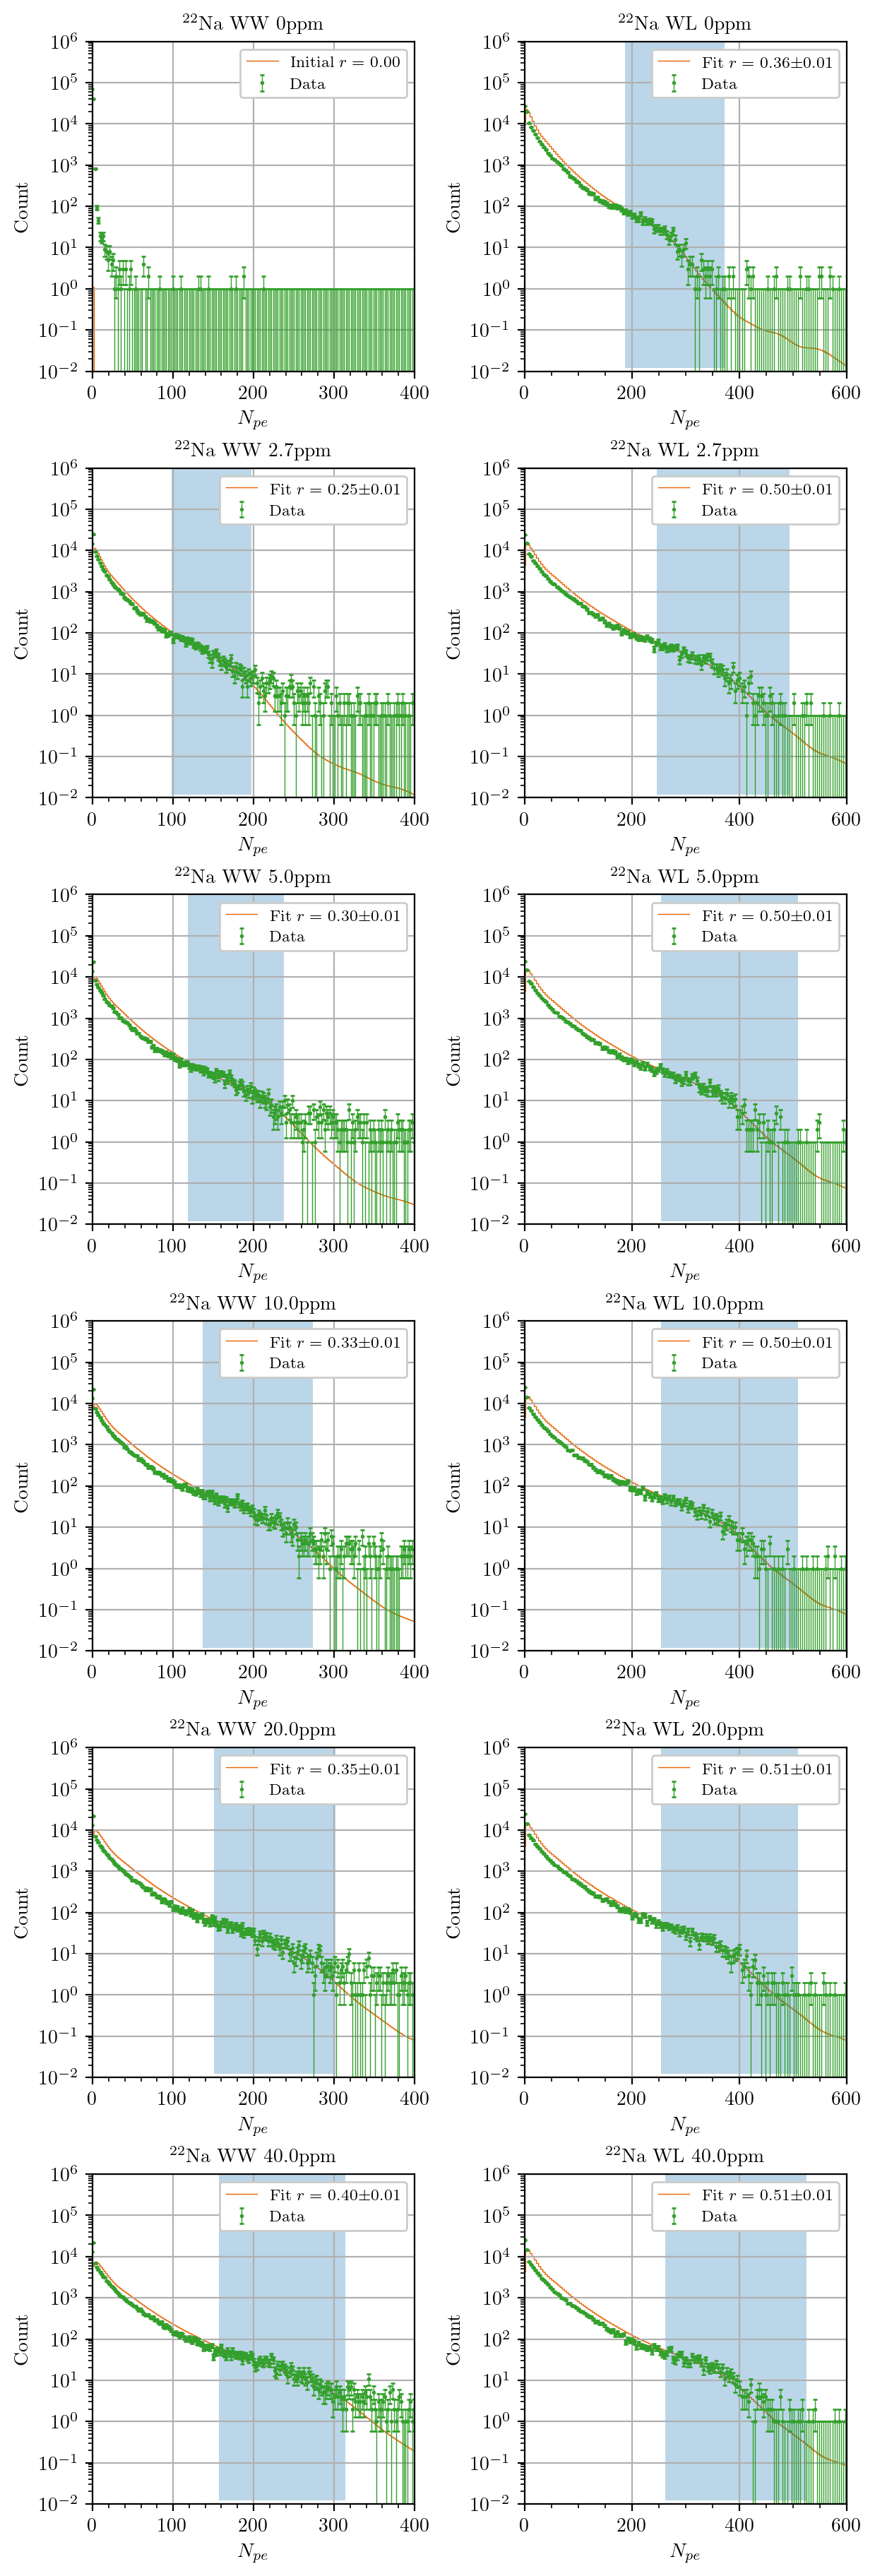

In [15]:
ly, ly_err = {}, {}
fig, axs = plt.subplots(len(xe_ppm), 2, sharex=False, sharey=False)
fig.set_size_inches(6, 3*len(xe_ppm))
fig.tight_layout(h_pad=3, w_pad=3)

for i,w in enumerate(window):
	ly[w] = []
	ly_err[w] = []
	for k,x in enumerate(xe_ppm):
		if w=='yes':
			left=spectra[k][w]['bins'][np.sum(np.cumsum(spectra[k][w]['counts'])/np.sum(spectra[k][w]['counts'])<0.98)]
			right=left*2
		else:
			left=spectra[k][w]['bins'][np.sum(np.cumsum(spectra[k][w]['counts'])/np.sum(spectra[k][w]['counts'])<0.99)]
			right=left*2			
		fit_range = (left,right)
		print(fit_range)
		bincen = (spectra[k][w]['bins'][1:]+spectra[k][w]['bins'][:-1])/2
		mask = (bincen<right) & (bincen>left)
		ymin, ymax = 1e-2,1e6
		p0 = [5e5,(left+right)/2/1000]
		# MC spectrum fit
		try:
			smear = spectrum.DetectorSmearing(
				fano=np.mean(calib[98]['fano'][[0,3,5,6]]) if w=='yes' else np.mean(calib[98]['fano'][[1,2,4,7]]),
				hist_in=hist_sim['Na-22']
			)
			par,cov = smear.fit_to_data(
				data=(spectra[k][w]['counts'],spectra[k][w]['bins']),
				sigma=spectra[k][w]['errs'],
				x0=p0,
				fit_range=fit_range
			)
			par_err = np.array([func.error_distance(df=2, sigma=1)*cov[j,j]**0.5 for j in range(len(par))])
			print(f'Na-22 {x}ppm '+('WL' if w=='no' else 'WW')+f' {par}')
			ly[w].append(par[1])
			ly_err[w].append(par_err[1])
			axs[k,i].stairs(*(smear.get_spectrum(spectra[k][w]['bins'],*par)), label='Fit '+r'$r=$'+f' {par[1]:.2f}'+r'$\pm$'+f'{par_err[1]:.2f}', color='C1', linewidth=0.5)
		except:
			print(f'Na-22 {x}ppm '+('WL' if w=='no' else 'WW')+' MC fit failed')
			ly[w].append(np.nan)
			ly_err[w].append(np.nan)
			axs[k,i].stairs(*(smear.get_spectrum(spectra[k][w]['bins'],*p0)), label='Initial '+r'$r=$'+f' {p0[1]:.2f}', color='C1', linewidth=0.5)


		axs[k,i].errorbar((spectra[k][w]['bins'][1:]+spectra[k][w]['bins'][:-1])/2,spectra[k][w]['counts'], yerr=spectra[k][w]['errs'],
			label='Data', color='C2', linewidth=0.5, capsize=1, fmt='o', markersize=1)
		axs[k,i].axvspan(*fit_range,ymin,ymax,alpha=0.3)
		axs[k,i].set_yscale('log')
		axs[k,i].set_ylim(ymin,ymax)
		axs[k,i].set_xlim(0, 400 if w=='yes' else 600)
		axs[k,i].legend(loc='upper right')
		axs[k,i].set_title(r'$^{22}\rm Na$ ' + ('WL' if w=='no' else 'WW') + f' {x}ppm ')
		axs[k,i].set_xlabel(r'$N_{pe}$',y=-0.02)
		axs[k,i].set_ylabel(r'Count')

## Relative Light Yield vs Xe Concentration

(0.0, 2.0)

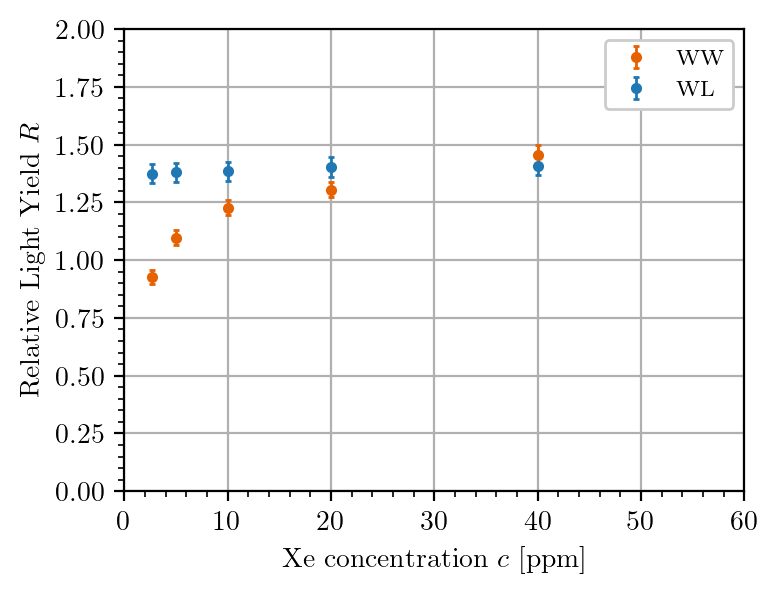

In [16]:
lyr, lyr_err = {}, {}
for i,w in enumerate(window):
	lyr[w] = np.array(ly[w])/ly['no'][0]
	lyr_err[w] = lyr[w]*((np.array(ly_err[w])/np.array(ly[w]))**2 + (ly_err['no'][0]/ly['no'][0])**2)**0.5
plt.figure(0,figsize=(4,3))
for j,w in enumerate(window):
	plt.errorbar(
		xe_ppm[1:],
		lyr[w][1:]* (1 if w=='no' else 4/3),
		yerr=lyr_err[w][1:],
		label='WW' if w=='yes' else 'WL', linestyle='', 
		linewidth=1, fmt=f'C{1-j}o', markersize=3, capsize=1
	)
plt.legend(loc='upper right')
plt.ylabel(r'Relative Light Yield $R$')
plt.xlabel(r'Xe concentration $c$ [ppm]')
plt.xlim(0,60)
plt.ylim(0,2)

In [17]:
# save to file
df = pd.DataFrame({
    'Xe ppm': xe_ppm[1:],
    'Ly WL': lyr['no'][1:],
	'Ly err WL': lyr_err['no'][1:],
    'Ly WW': lyr['yes'][1:],
	'Ly err WW': lyr_err['yes'][1:]
})
df.to_csv('/home/as111/sipm-analysis/light_yield_ratio_liq6.csv', index=False)